In [ ]:
# Setup and imports

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

# Import GcStar from causalised-GC
import importlib.util
import sys
CAUSALISED_GC_RELATIVE_PATH = Path("src/markovianity_diagnostic/core/causalised-GC.py")
PROJECT_ROOT = next(
    (p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (p / CAUSALISED_GC_RELATIVE_PATH).exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Could not find '{CAUSALISED_GC_RELATIVE_PATH}' from {Path.cwd().resolve()}"
    )
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))
CAUSALISED_GC_PATH = PROJECT_ROOT / CAUSALISED_GC_RELATIVE_PATH
spec = importlib.util.spec_from_file_location("causalised_gc", CAUSALISED_GC_PATH)
causalised_gc = importlib.util.module_from_spec(spec)
sys.modules["causalised_gc"] = causalised_gc
assert spec.loader is not None
spec.loader.exec_module(causalised_gc)
GcStar = causalised_gc.GcStar

from markovianity_diagnostic.core.utils import adj_mtx, continuous_noise_fun
from markovianity_diagnostic.experiments.graph_metrics import compute_graph_stability_metrics

print("✓ All imports successful")

No GPU automatically detected. Setting SETTINGS.GPU to 0, and SETTINGS.NJOBS to cpu_count.


In [2]:
metrics, N_PASTS, num = [], list(range(2,8)), 10
shd_sids = []
for a in tqdm(range(num)):
    n_neur,l,alpha,beta,n_lags = np.random.randint(20,30,1)[0],np.random.randint(5000,10000,1)[0],0.01,0.001,2

    #     creating A matrix

    A = np.random.choice([0,0.5,0.85], p=[0.9,0.035,0.065], size=(n_neur,n_neur)) ### A is not the adjacency matrix in the typical sense
    A[0:10,0:10] =np.zeros((10,10))
    for n, i in enumerate(A):
        A[n][n]=1
    for n, i in enumerate(A):
        A[n]=A[n]/np.sum(A[n])

    #     creating B matrix
    mask = np.random.random((A.shape[0],A.shape[1]))>0.55
    np.fill_diagonal(mask,1)
    B_ = np.multiply(A,1-mask)
    A_ = np.multiply(A,mask)

    A = np.logical_or(A_, B_)

    noise = continuous_noise_fun(num=n_neur,l=l)

    X = np.zeros((A.shape[0],l)).T
    X[0] = np.random.randn(A.shape[0])
    for i, row in enumerate(X[:-1]):
        X[i+1] = A_ @ X[i] + B_ @ X[i-1] + np.random.normal(0,0.25,A.shape[0]) + noise[:, i]
    X=X.T

    print(f'Data {a} of {num} with {X.shape[0]} vars')

    # fit algorithm to data
    met = np.zeros((len(N_PASTS), 6))
    shd_sid_fgc = []
    infs_fgc = []
    conf_mtx_fgc = []
    metrics_fgc = []

    for k, n_past in enumerate(N_PASTS):
        print(n_past)

        # intantiate the GcStar()
        gcstar = GcStar(n_perm = 1000, n_pasts = n_past, n_lags = n_lags, temporal = True, method="cgc")
        gcstar.fit(X, verbose=0)

        # compute metrics
        inf = gcstar.get_connectivity_matrix(alpha=alpha, beta=beta, simulation=True)
        infs_fgc.append(inf)
        conf_mtx_fgc.append(gcstar.compute_confusion_matrix(A, simulation=True))
        met[k] = np.round(gcstar.all_metrics(), 4)
        metrics_fgc.append(np.round(gcstar.all_metrics(),4))
        shd_sid_fgc.append(np.round(gcstar.compute_shd_sid(A, inf, simulation=True),4))

    metrics.append(met)
    shd_sids.append(shd_sid_fgc)


  0%|          | 0/10 [00:00<?, ?it/s]

Data 0 of 10 with 25 vars
2
3
4
5
6
7
Data 1 of 10 with 25 vars
2
3
4
5
6
7
Data 2 of 10 with 25 vars
2
3
4
5
6
7
Data 3 of 10 with 27 vars
2
3
4
5
6
7
Data 4 of 10 with 27 vars
2
3
4
5
6
7
Data 5 of 10 with 27 vars
2
3
4
5
6
7
Data 6 of 10 with 29 vars
2
3
4
5
6
7
Data 7 of 10 with 29 vars
2
3
4
5
6
7
Data 8 of 10 with 21 vars
2
3
4
5
6
7
Data 9 of 10 with 28 vars
2
3
4
5
6
7


In [3]:
for met in metrics:
    print(met)

[[0.936  0.9216 0.5663 0.0074 0.7794 0.7015]
 [0.9312 0.8846 0.5542 0.0111 0.7716 0.6815]
 [0.9296 0.8824 0.5422 0.0111 0.7655 0.6716]
 [0.936  0.9574 0.5422 0.0037 0.7692 0.6923]
 [0.9344 0.9375 0.5422 0.0055 0.7683 0.687 ]
 [0.9344 0.9375 0.5422 0.0055 0.7683 0.687 ]]
[[0.9264 0.84   0.525  0.0147 0.7552 0.6462]
 [0.9264 0.84   0.525  0.0147 0.7552 0.6462]
 [0.9328 0.913  0.525  0.0073 0.7588 0.6667]
 [0.9344 0.9333 0.525  0.0055 0.7597 0.672 ]
 [0.9344 0.9333 0.525  0.0055 0.7597 0.672 ]
 [0.9344 0.9333 0.525  0.0055 0.7597 0.672 ]]
[[0.9328 0.7812 0.641  0.0256 0.8077 0.7042]
 [0.936  0.8167 0.6282 0.0201 0.804  0.7101]
 [0.9408 0.8596 0.6282 0.0146 0.8068 0.7259]
 [0.9408 0.8596 0.6282 0.0146 0.8068 0.7259]
 [0.944  0.8909 0.6282 0.011  0.8086 0.7368]
 [0.9472 0.9245 0.6282 0.0073 0.8104 0.7481]]
[[0.9342 0.9028 0.6132 0.0112 0.801  0.7303]
 [0.9355 0.9155 0.6132 0.0096 0.8018 0.7345]
 [0.9396 0.9429 0.6226 0.0064 0.8081 0.75  ]
 [0.9424 0.9848 0.6132 0.0016 0.8058 0.7558]
 [0.943

In [4]:
Metrics = np.zeros((num,len(N_PASTS), 6))
for i, met in enumerate(metrics):
    Metrics[i] = met
np.mean(Metrics[:,0,0])

np.float64(0.93854)

In [5]:
np.std(Metrics,axis=0)

array([[0.01146815, 0.04586254, 0.05085151, 0.00553321, 0.02585047,
        0.04150672],
       [0.01056996, 0.04487619, 0.04745998, 0.00495706, 0.02397812,
        0.03869115],
       [0.00899761, 0.03249739, 0.0485569 , 0.00338882, 0.02383822,
        0.03475676],
       [0.00838033, 0.03959318, 0.05184188, 0.00392219, 0.02500828,
        0.03495626],
       [0.00882171, 0.03386316, 0.04626426, 0.00320514, 0.02292306,
        0.03502806],
       [0.00832135, 0.03382533, 0.04403366, 0.00294871, 0.02174049,
        0.03300095]])

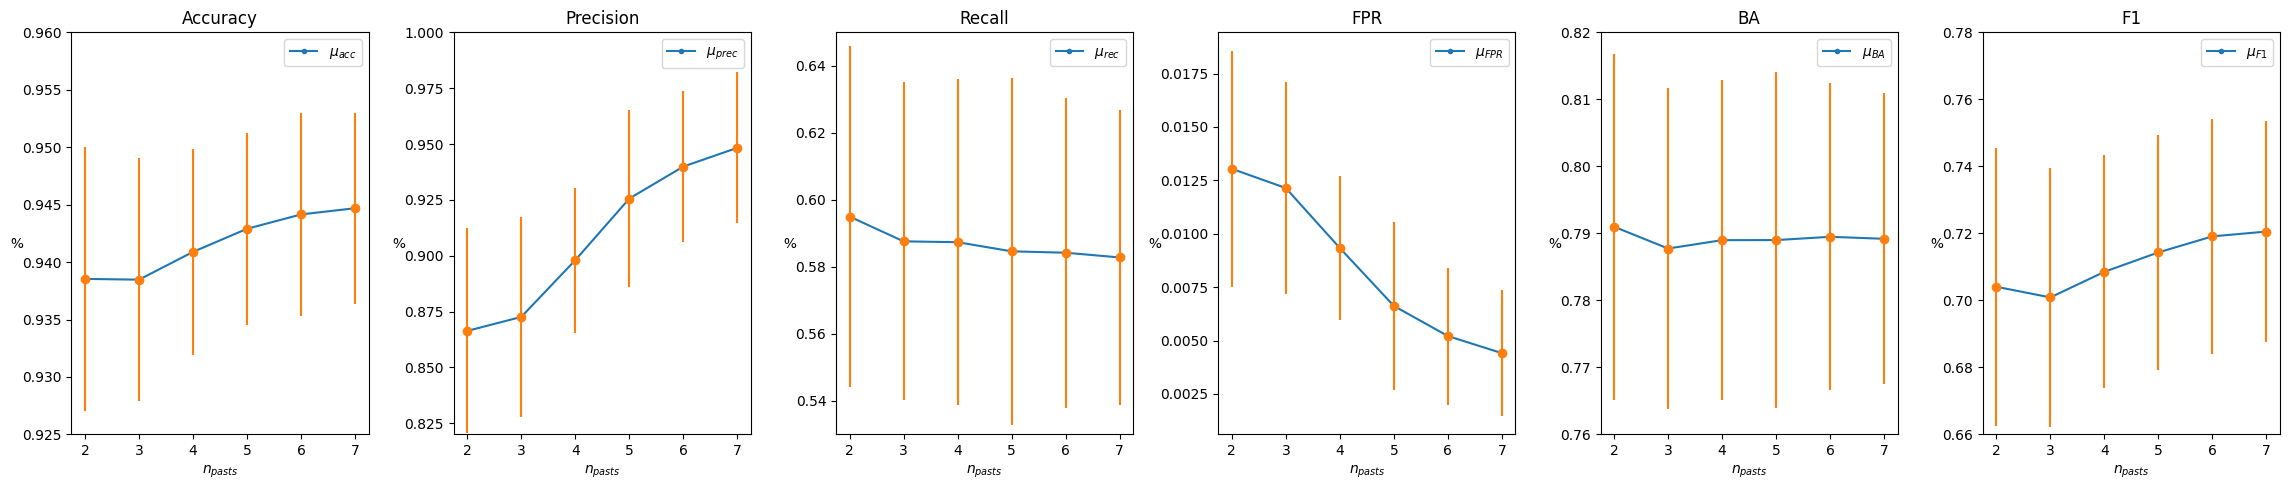

In [12]:
fig, ax = plt.subplots(1, 6, figsize = (23, 5))
labels = ['Accuracy', 'Precision', 'Recall', 'FPR', 'BA', 'F1']
lab = ['$\mu_{acc}$','$\mu_{prec}$', '$\mu_{rec}$', '$\mu_{FPR}$', '$\mu_{BA}$', '$\mu_{F1}$']
for i in range(Metrics.shape[2]):
    ax[i].plot(range(2, 2 + Metrics.shape[1]),
               np.mean(Metrics, axis = 0)[:, i],
               marker = '.', label = lab[i])

    ax[i].errorbar(range(2, 2 + Metrics.shape[1]),
                   np.mean(Metrics, axis = 0)[:, i],
                   yerr = np.std(Metrics, axis = 0)[:, i],
                   fmt='o')
    ax[i].set_xticks(range(2, 2 + Metrics.shape[1]),
                     list(range(2, 2 + Metrics.shape[1])))
    ax[i].set_xlabel('$n_{pasts}$')
    ax[i].set_ylabel('%', rotation = 180)
    ax[i].set_title(f'{labels[i]}')
    if labels[i] == 'Accuracy':
        ax[i].set_ylim(0.925, .96)
    if labels[i] == 'Precision':
        ax[i].set_ylim(0.82, 1)
    if labels[i] == 'Recall':
        ax[i].set_ylim(0.53, .65)
    if labels[i] == 'BA':
        ax[i].set_ylim(0.76, .82)
    if labels[i] == 'F1':
        ax[i].set_ylim(0.66, .78)
    ax[i].legend()
    plt.tight_layout()

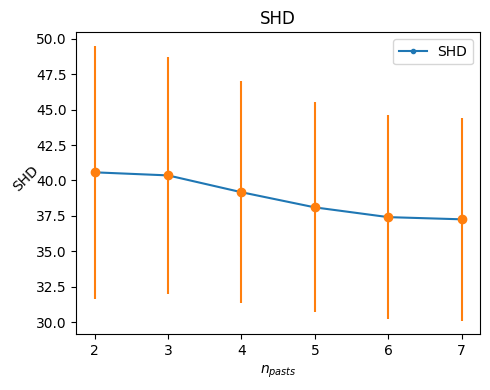

In [9]:
shds = np.array(shd_sids)
fig, ax = plt.subplots(1, 1, figsize = (5,4))
ax.plot(range(2, 2 + shds.shape[1]),
        np.mean(shds, axis = 0),
        marker = '.', label = 'SHD')
ax.errorbar(range(2, 2 + shds.shape[1]),
            np.mean(shds, axis = 0),
            yerr = np.std(shds, axis = 0),
            fmt='o')
ax.set_xticks(range(2,2+shds.shape[1]), list(range(2, 2+shds.shape[1])))
ax.set_xlabel('$n_{pasts}$')
ax.set_ylabel('SHD', rotation = 45)
ax.set_title(f'SHD')
ax.legend()
plt.tight_layout()